# Lichens Hyperspectral Wavelength Selection

This notebook demonstrates the complete wavelength selection pipeline using the `spectral_select` module.

## Workflow:
1. **Load Data** - Load preprocessed hyperspectral data
2. **Create/Load Mask** - Define region of interest (optional)
3. **Configure Analysis** - Set up wavelength selection parameters
4. **Run Analysis** - Train autoencoder and select wavelengths
5. **Visualize Results** - Generate plots and inspect selected bands

## 1. Setup and Imports

In [1]:
from pathlib import Path
import numpy as np
from PIL import Image

from spectral_select import (
    SpectraData, 
    Config, 
    Analyzer, 
    Visualizer,
    ROIWidget
)

print("Imports complete!")

Imports complete!


## 2. Load Data

In [2]:
# Load the preprocessed Lichens dataset
DATA_PATH = "Data/processed/LichensProcessed/data_cutoff_60nm_exposure_max_power_min.pkl"

data = SpectraData.from_pickle(DATA_PATH)

print(f"Spatial shape: {data.spatial_shape}")
print(f"Excitations: {list(data.excitations.keys())}")
print(f"Total pixels: {data.spatial_shape[0] * data.spatial_shape[1]:,}")

Spatial shape: (256, 348)
Excitations: [310.0, 325.0, 340.0, 365.0, 385.0, 400.0, 415.0, 430.0]
Total pixels: 89,088


## 3. Mask Creation (Optional)

You can either:
- **Option A**: Load a previously saved mask
- **Option B**: Create a new mask interactively

If no mask is needed, skip to Section 4.

### Option A: Load Existing Mask

In [3]:
# Load a previously saved mask
MASK_PATH = "masks/lichens_roi.png"

if Path(MASK_PATH).exists():
    mask_img = Image.open(MASK_PATH).convert("L")
    mask = np.array(mask_img) > 0
    data.mask = mask
    print(f"Mask loaded: {mask.sum():,} / {mask.size:,} pixels selected ({100*mask.sum()/mask.size:.1f}%)")
else:
    print(f"No mask found at {MASK_PATH}. Running without mask or create one below.")

Mask loaded: 0 / 89,088 pixels selected (0.0%)


### Option B: Create New Mask Interactively

Run the cell below to draw regions of interest. Use:
- **Lasso tool**: Freehand drawing
- **Rectangle tool**: Rectangular selection

After drawing, run the "Save Mask" cell.

In [3]:
%matplotlib widget

# Create interactive ROI widget
widget = ROIWidget(data, tool="lasso")  # or tool="rectangle"
widget.display()

In [4]:
# Apply the drawn mask to data (only if something was drawn)
new_mask = widget.get_mask()
if new_mask is not None and new_mask.any():
    data.mask = new_mask
    print(f"New mask applied: {new_mask.sum():,} / {new_mask.size:,} pixels selected")
elif data.mask is not None and data.mask.any():
    print(f"Keeping existing mask: {data.mask.sum():,} / {data.mask.size:,} pixels selected")
else:
    print("No mask set. Using all pixels.")

New mask applied: 3,647 / 89,088 pixels selected


In [5]:
# Save the mask for future use
MASK_SAVE_PATH = Path("masks/lichens_roi.png")
MASK_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
widget.save_mask(MASK_SAVE_PATH)
print(f"Mask saved to {MASK_SAVE_PATH}")

Mask saved to masks/lichens_roi.png


## 4. Configure Analysis

The `Config` class controls all analysis parameters. Key options:

| Parameter | Description | Options |
|-----------|-------------|--------|
| `n_bands_to_select` | Number of wavelengths to select | 10-50 typical |
| `training_epochs` | Autoencoder training iterations | 100 (fast) to 500+ (quality) |
| `dimension_selection_method` | How to pick important latent dims | `"activation"`, `"variance"`, `"pca"` |
| `use_diversity_constraint` | Enforce spectral diversity | `True`/`False` |
| `device` | Computation device | `"cpu"` or `"cuda"` |

In [7]:
# Configure the wavelength selection analysis
config = Config(
    sample_name="LichensProcessed",
    
    # Selection parameters
    n_bands_to_select=30,
    
    # Training parameters
    training_epochs=100,  # Increase to 500+ for publication quality
    
    # Device
    device="cpu",  # Use "cuda" if you have a GPU
    
    # Optional: Enable diversity constraint for better spectral coverage
    # use_diversity_constraint=True,
    # diversity_method="mmr",
    # lambda_diversity=0.3,
)

print(f"Configuration created:")
print(f"  Sample: {config.sample_name}")
print(f"  Bands to select: {config.n_bands_to_select}")
print(f"  Training epochs: {config.training_epochs}")
print(f"  Model path: {config.model_path}")

Configuration created:
  Sample: LichensProcessed
  Bands to select: 30
  Training epochs: 100
  Model path: model_output/LichensProcessed/model.pth


## 5. Run Analysis

This will:
1. Load or train the autoencoder model (cached automatically)
2. Compute baseline latent representations
3. Perturb latent space to measure wavelength influence
4. Rank and select top wavelengths

In [8]:
# Create analyzer and run
analyzer = Analyzer(config)
analyzer.fit(data)

print("\nAnalysis complete!")

Preparing data for 8 excitation wavelengths...
Emission band lengths for each excitation wavelength:
  - Excitation 310.0 nm: 18 bands
  - Excitation 325.0 nm: 18 bands
  - Excitation 340.0 nm: 20 bands
  - Excitation 365.0 nm: 24 bands
  - Excitation 385.0 nm: 26 bands
  - Excitation 400.0 nm: 27 bands
  - Excitation 415.0 nm: 27 bands
  - Excitation 430.0 nm: 27 bands
Mask processed. Valid pixels: 8176.0/89088 (9.18%)
Global data range (valid values only): [0.0000, 120941.2608]
Data normalized to range [0, 1] using global normalization
Data preparation complete. Spatial dimensions: 256x348


/Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/spectral_select/analyzer.py:1070: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  "std": torch.std(latent_flat, dim=0),



Analysis complete!


## 6. View Results

In [9]:
# Print top selected wavelengths
print("=" * 60)
print("TOP 15 SELECTED WAVELENGTHS")
print("=" * 60)
print(f"{'Rank':<6} {'Excitation':<12} {'Emission':<12} {'Score':<10}")
print("-" * 60)

for i, band in enumerate(analyzer.result.selected_bands[:15], 1):
    print(f"{i:<6} {band.excitation_nm:<12.0f} {band.emission_nm:<12.1f} {band.influence_score:<10.4f}")

print("=" * 60)
print(f"Total bands selected: {len(analyzer.result.selected_bands)}")

TOP 15 SELECTED WAVELENGTHS
Rank   Excitation   Emission     Score     
------------------------------------------------------------
1      310          420.0        0.0000    
2      310          430.0        0.0000    
3      310          440.0        0.0000    
4      310          450.0        0.0000    
5      310          460.0        0.0000    
6      310          470.0        0.0000    
7      310          480.0        0.0000    
8      310          490.0        0.0000    
9      310          500.0        0.0000    
10     310          510.0        0.0000    
11     310          520.0        0.0000    
12     310          530.0        0.0000    
13     310          540.0        0.0000    
14     310          550.0        0.0000    
15     310          690.0        0.0000    
Total bands selected: 30


## 7. Visualizations

In [7]:
%matplotlib inline

# Create visualizer from analyzer
viz = Visualizer.from_analyzer(analyzer)

NameError: name 'analyzer' is not defined

PosixPath('visualizations/LichensProcessed/influence_heatmap.png')

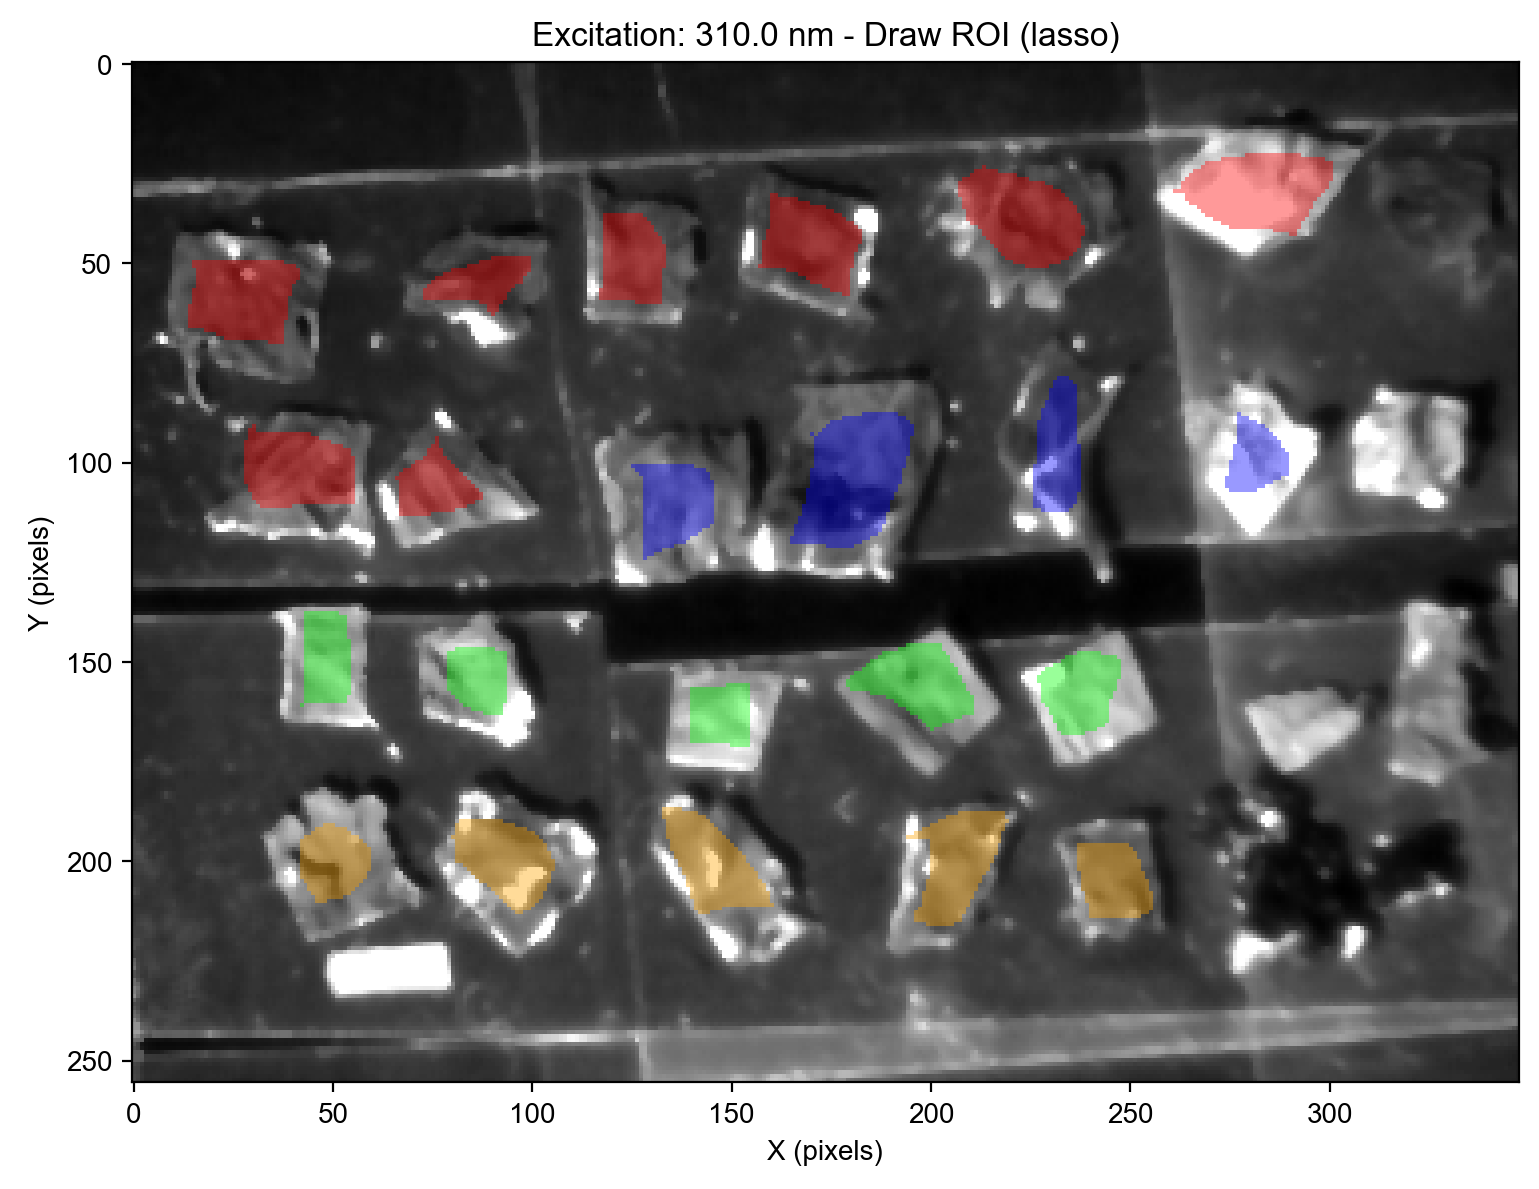

In [11]:
# Influence heatmap - shows which wavelengths are most important per excitation
viz.plot_influence_heatmap()

In [6]:
# Wavelength scatter - shows selected bands across the spectrum
viz.plot_wavelength_scatter()

NameError: name 'viz' is not defined

In [13]:
# Breakdown by excitation wavelength
print("\nSelected bands per excitation:")
print("-" * 40)

from collections import Counter
excitation_counts = Counter(b.excitation_nm for b in analyzer.result.selected_bands)

for ex in sorted(excitation_counts.keys()):
    count = excitation_counts[ex]
    bar = "*" * count
    print(f"{ex:>6.0f} nm: {count:>2} {bar}")


Selected bands per excitation:
----------------------------------------
   310 nm: 18 ******************
   325 nm: 12 ************


## 8. Export Results (Optional)

In [14]:
# Get reduced data with only selected wavelengths
reduced_data = analyzer.transform(data)

original_bands = sum(ex.cube.shape[2] for ex in data.excitations.values())
reduced_bands = sum(ex.cube.shape[2] for ex in reduced_data.excitations.values())

print(f"Original: {data.spatial_shape} x {original_bands} bands")
print(f"Reduced:  {reduced_data.spatial_shape} x {reduced_bands} bands")
print(f"Compression: {original_bands} -> {reduced_bands} bands ({100*reduced_bands/original_bands:.1f}%)")

Original data shape: (256, 348) x 187 bands


AttributeError: 'SpectraData' object has no attribute 'shape'

In [ ]:
# Save selected wavelengths to CSV
import pandas as pd

results_df = pd.DataFrame([
    {
        "rank": band.rank,
        "excitation_nm": band.excitation_nm,
        "emission_nm": band.emission_nm,
        "influence_score": band.influence_score
    }
    for band in analyzer.result.selected_bands
])

output_path = Path("results") / config.sample_name / "selected_wavelengths.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(output_path, index=False)
print(f"Results saved to {output_path}")

results_df.head(10)

## 9. Clustering with Selected Wavelengths

Run clustering on the reduced data to segment the image.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Get reduced data as numpy array for clustering
reduced_data = analyzer.transform(data)

# Concatenate all excitations into a single feature matrix
feature_list = []
for ex_nm in reduced_data.excitation_wavelengths:
    ex = reduced_data.get_excitation(ex_nm)
    feature_list.append(ex.cube)

features = np.concatenate(feature_list, axis=2)
height, width, n_features = features.shape
print(f"Feature matrix: {height}x{width} pixels, {n_features} features")

# Flatten for clustering
X = features.reshape(-1, n_features)

# Apply mask if exists
if data.mask is not None:
    mask_flat = data.mask.flatten()
    X_masked = X[mask_flat > 0]
    print(f"Using {X_masked.shape[0]} masked pixels for clustering")
else:
    X_masked = X
    mask_flat = np.ones(X.shape[0])

# Run KMeans clustering
n_clusters = 4  # Adjust based on expected number of materials
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_masked = kmeans.fit_predict(X_masked)

# Reconstruct full cluster map
cluster_map = np.full(height * width, -1, dtype=int)
cluster_map[mask_flat > 0] = labels_masked
cluster_map = cluster_map.reshape(height, width)

# Calculate silhouette score
sil_score = silhouette_score(X_masked, labels_masked)
print(f"Silhouette Score: {sil_score:.3f}")

# Print cluster statistics
print(f"
Cluster distribution:")
for i in range(n_clusters):
    count = (labels_masked == i).sum()
    pct = 100 * count / len(labels_masked)
    print(f"  Cluster {i}: {count:,} pixels ({pct:.1f}%)")

In [ ]:
# Visualize cluster map
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original image (mean intensity)
first_ex = list(data.excitations.values())[0]
mean_img = first_ex.cube.mean(axis=2)
axes[0].imshow(mean_img, cmap="gray")
axes[0].set_title("Original Image (Mean Intensity)")
axes[0].axis("off")

# Cluster map
cmap = plt.cm.get_cmap("tab10", n_clusters)
cluster_display = np.ma.masked_where(cluster_map == -1, cluster_map)
im = axes[1].imshow(cluster_display, cmap=cmap, vmin=0, vmax=n_clusters-1)
axes[1].set_title(f"Cluster Map ({n_clusters} clusters)")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], label="Cluster ID")

plt.tight_layout()
plt.savefig("cluster_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cluster_map.png")

In [ ]:
# Generate all available visualizations
paths = viz.plot_all()
print(f"
Generated {len(paths)} visualizations")